In [ ]:
#!pip install ucimlrepo
!pip install interpret shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 37.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 107.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 22.0 MB/s eta 0:00:00
  Created wheel for dash-cytoscape: filename=dash_cytoscape-1.0.2-py3-none-any.whl size=4010717 sha256=da3773fb9c5586c08e1a3a557b42874e63bc60f5b5f872aad4aca15994891f70
  Stored in directory: /root/.cache/pip/wheels/0c/db/f6/9dcb225e9adf45dfef7135427

### EDA and Feature Engineering

In [ ]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


credit_approval = fetch_ucirepo(id=27)
print(credit_approval.variables)

   name     role         type demographic description units missing_values
0   A16   Target  Categorical        None        None  None             no
1   A15  Feature   Continuous        None        None  None             no
2   A14  Feature   Continuous        None        None  None            yes
3   A13  Feature  Categorical        None        None  None             no
4   A12  Feature  Categorical        None        None  None             no
5   A11  Feature   Continuous        None        None  None             no
6   A10  Feature  Categorical        None        None  None             no
7    A9  Feature  Categorical        None        None  None             no
8    A8  Feature   Continuous        None        None  None             no
9    A7  Feature  Categorical        None        None  None            yes
10   A6  Feature  Categorical        None        None  None            yes
11   A5  Feature  Categorical        None        None  None            yes
12   A4  Feature  Categor

## Column Reference (best guess)

The mapping below is the conventional interpretation widely used in the ML literature, inferred by cross-referencing with the related Statlog Australian Credit Approval dataset and examining value distributions.

| Column | Type | Conventional Meaning |
|--------|------|----------------------|
| A1 | Categorical (b, a) | Gender |
| A2 | Continuous | Age |
| A3 | Continuous | Debt |
| A4 | Categorical (u, y, l, t) | Marital status |
| A5 | Categorical (g, p, gg) | Bank customer / account type |
| A6 | Categorical (14 levels) | Education level / occupation category |
| A7 | Categorical (9 levels) | Ethnicity |
| A8 | Continuous | Years employed |
| A9 | Categorical (t, f) | Prior default |
| A10 | Categorical (t, f) | Currently employed |
| A11 | Continuous | Credit score |
| A12 | Categorical (t, f) | Driver's license |
| A13 | Categorical (g, p, s) | Citizenship status |
| A14 | Continuous | Zip code |
| A15 | Continuous | Income |
| A16 | Categorical (+, -) | **Approval (target)** |

*Note: A1, A4, and A7 correspond to protected attributes (gender, marital status, ethnicity) under fair-lending regulations. Their inclusion in a predictive model would warrant fairness analysis in a real-world deployment.*

In [ ]:
var_data = credit_approval.variables
X = credit_approval.data.features
y = credit_approval.data.targets

#drop missing values, combine and then split X,y so we remove rows for both
to_drop = ["A16"]
X["A16"] = y["A16"]
X = X.dropna()
y = X["A16"]
X = X.drop(columns=["A16"])

#one hot encode categorical vars
categorical_vars = var_data[var_data["type"] == "Categorical"]["name"].to_list()
continuous_vars = var_data[var_data["type"] == "Continuous"]["name"].to_list()
for col in to_drop:
  categorical_vars.remove(col)

X = pd.get_dummies(X,
                   columns=categorical_vars,
                   drop_first=True)

bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)


y = y.map({"+":1, "-": 0})

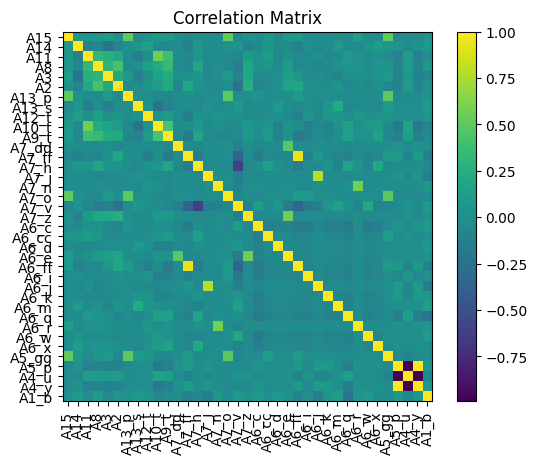

In [ ]:
corr = X.corr()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
def drop_high_corr_features(df, threshold=0.95):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    to_drop = [
        column for column in upper.columns
        if any(upper[column] > threshold)
    ]

    return df.drop(columns=to_drop), to_drop
X, dropped = drop_high_corr_features(X, threshold=0.95)
print("Dropped columns:", dropped)

Dropped columns: ['A4_u', 'A4_y']


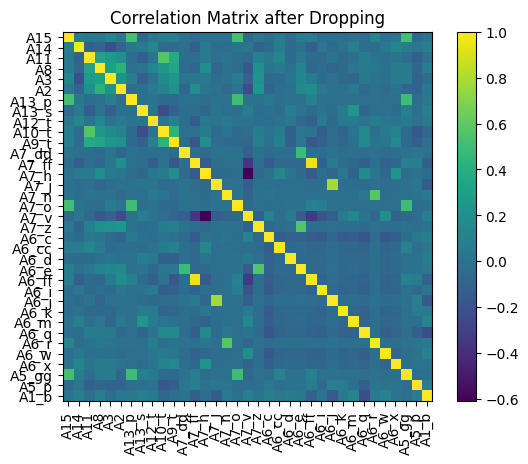

In [ ]:
corr = X.corr()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix after Dropping")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
scaler = StandardScaler()
X_train[continuous_vars] = scaler.fit_transform(X_train[continuous_vars])
X_test[continuous_vars] = scaler.transform(X_test[continuous_vars])


### Modeling Section

In [ ]:
from sklearn.metrics import accuracy_score
def calc_accuracy(model):
  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)
  train_acc = accuracy_score(y_train, y_train_pred)
  test_acc = accuracy_score(y_test, y_test_pred)

  print(f"Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

In [ ]:
#Each true positive gives us 1 profit, each false positive costs us r
R_VALUES  = np.logspace(start=-2, stop=6, base=2)

def profit_curve(y_true, y_hat, r):
    y_true  = np.asarray(y_true)
    y_hat = np.asarray(y_hat)

    thresholds = np.sort(np.unique(y_hat))

    opt_threshold = -1
    max_profit = -1
    for t in thresholds:
        predicted_pos = y_hat >= t
        tp = int(np.sum((predicted_pos) & (y_true == 1)))
        fp = int(np.sum((predicted_pos) & (y_true == 0)))
        profit = (tp - r * fp) / len(y_true)
        if (profit > max_profit):
          max_profit = profit
          per_pred = (tp - r * fp) / (tp + fp)
          opt_threshold = np.mean((predicted_pos) & (y_true == 1))

    return max_profit, opt_threshold, per_pred

def plot_thresholds(y_true, y_hat, title="Optimum Threshold and Max Profit vs R (log scale)"):
  opt_thresholds = []
  max_profits    = []
  per_preds = []
  for r in R_VALUES:
    max_profit, opt_threshold, per_pred = profit_curve(y_true, y_hat, r)
    opt_thresholds.append(opt_threshold)
    max_profits.append(max_profit)
    per_preds.append(per_pred)
  fig, ax = plt.subplots()

  ax.plot(R_VALUES, opt_thresholds, color='blue', label='Threshold')
  ax.plot(R_VALUES, max_profits, color='red', label='Profit Per Person')
  ax.plot(R_VALUES, per_preds, color="orange", label="Profit Per Prediction")
  ax.set_xlabel('Relative Negative Impact of FP vs TP')
  ax.set_ylabel('', color='blue')
  ax.set_ylim(0, 1)

  ax.set_xscale('log')
  ax.legend()



  plt.title(title)
  plt.show()
def calc_thresholds(model):
  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)
  plot_thresholds(y_test, y_test_pred, "Optimum Threshold and Max Profit vs R on Train Data (log scale)")
  plot_thresholds(y_train, y_train_pred, "Optimum Threshold and Max Profit vs R on Test Data (log scale)")


### Decision Tree (no clustering)

Train Acc: 0.8755, Test Acc: 0.8473


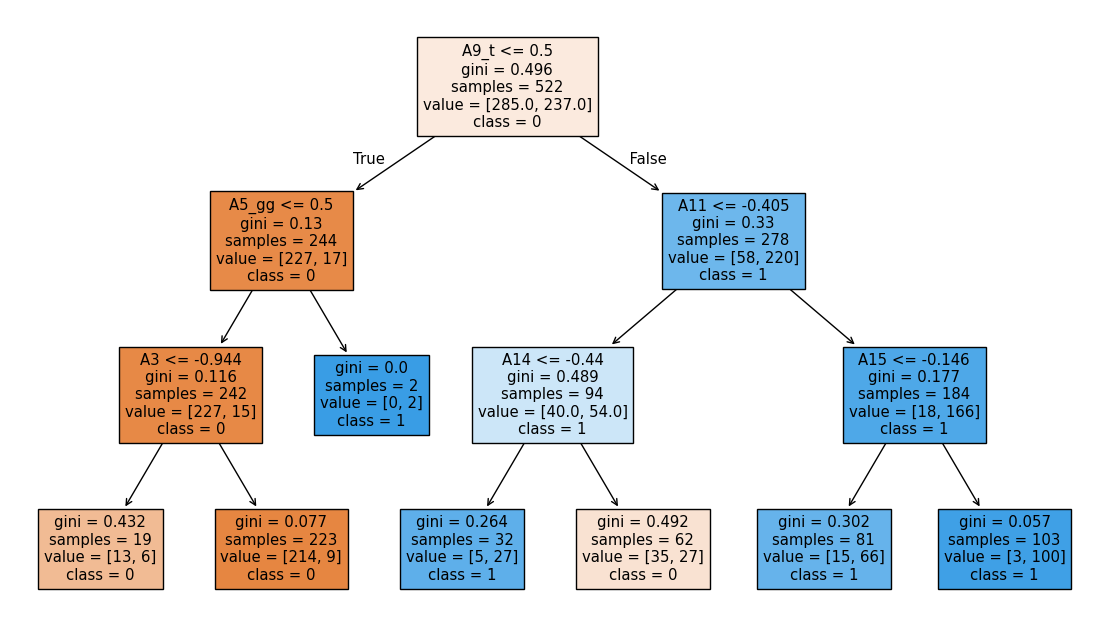

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=10,
    random_state=0
)

model.fit(X_train, y_train)
calc_accuracy(model)
from sklearn.tree import plot_tree

plt.figure(figsize=(14, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=[str(c) for c in model.classes_],
    filled=True
)
plt.show()

### Logistic Regression

Train Acc: 0.8755, Test Acc: 0.8855


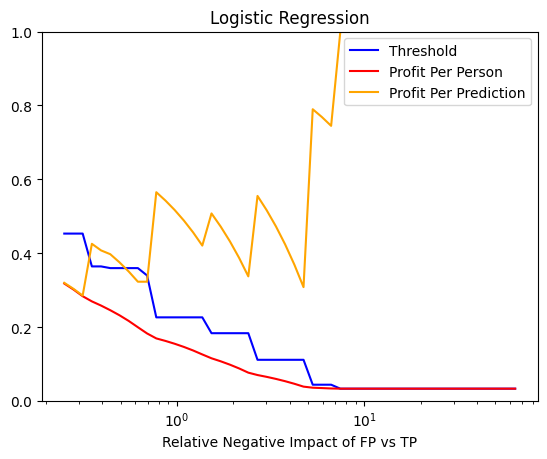

Coefficients


,0,1
0,A15,1.461706
1,A14,-0.248043
2,A11,0.563786
3,A8,0.334569
4,A3,-0.052733
5,A2,0.039984
6,A13_p,-0.077698
7,A13_s,0.17077
8,A12_t,-0.126899
9,A10_t,0.517809


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10_000)
model.fit(X_train, y_train)
calc_accuracy(model)
plot_thresholds(y, model.decision_function(X), title="Logistic Regression")
print(f"Coefficients")
pd.DataFrame([X.columns, model.coef_[0]]).T

### Decision Tree (w/ clustering)

K=2: silhouette=0.3115
K=3: silhouette=0.2988
K=4: silhouette=0.1297
K=5: silhouette=0.1204
K=6: silhouette=0.1295
K=7: silhouette=0.1348

Best K = 2

Chosen K = 4


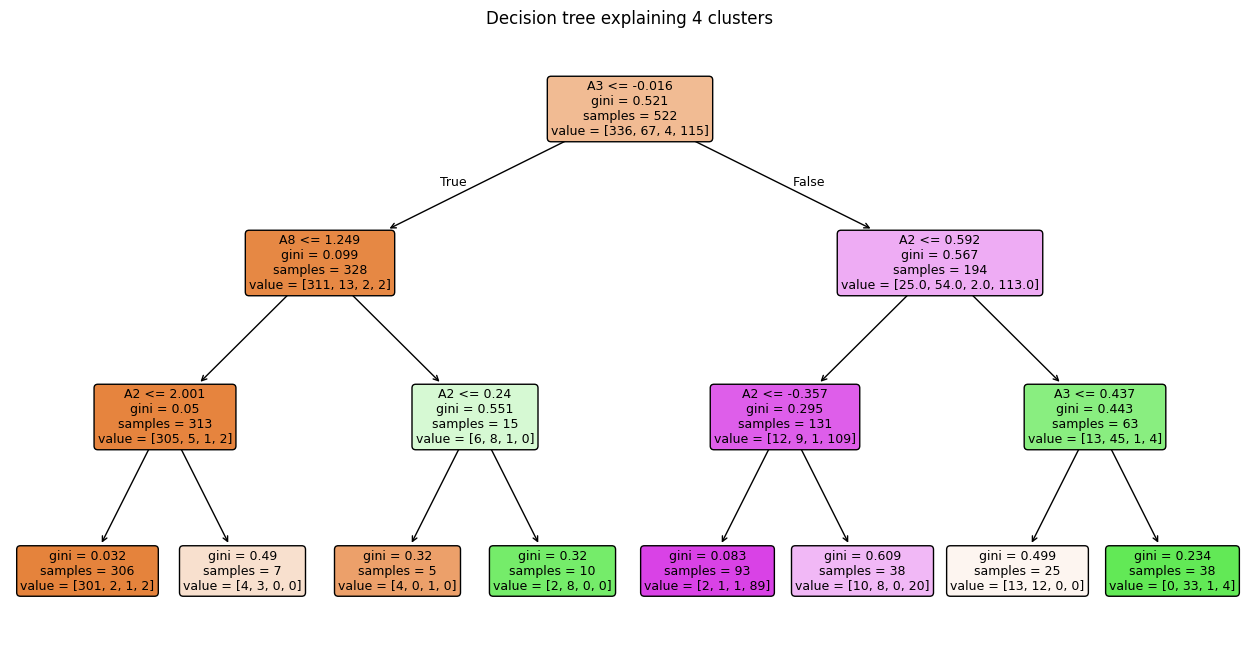


Cluster -> predicted label: {0: 0, 1: 1, 2: 1, 3: 1}
Train Acc: 0.6494, Test Acc: 0.6870


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

best_k, best_score = 2, -1
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_train)
    score = silhouette_score(X_train, km.labels_)
    print(f"K={k}: silhouette={score:.4f}")
    if score > best_score:
        best_k, best_score = k, score
print(f"\nBest K = {best_k}")

######### CHOSE OWN K IF YOU WANT ########
chose_own_K = True
if chose_own_K:
  best_k = 4
print(f"\nChosen K = {best_k}")


kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit(X_train)
train_clusters = kmeans.labels_
test_clusters = kmeans.predict(X_test)

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, train_clusters)

plt.figure(figsize=(16, 8))
plot_tree(tree, feature_names=X_train.columns, filled=True, rounded=True, fontsize=9)
plt.title(f"Decision tree explaining {best_k} clusters")
plt.show()

cluster_to_label = {}
for c in range(best_k):
    mask = train_clusters == c
    cluster_to_label[c] = int(round(y_train[mask].mean()))
print(f"\nCluster -> predicted label: {cluster_to_label}")

y_train_pred = np.array([cluster_to_label[c] for c in train_clusters])
y_test_pred  = np.array([cluster_to_label[c] for c in test_clusters])
print(f"Train Acc: {accuracy_score(y_train, y_train_pred):.4f}, "
      f"Test Acc: {accuracy_score(y_test, y_test_pred):.4f}")

Interpretability Analysis: Focused on continuous features (age, income) rather than the one-hot variables.

### SHAP/Explainable Boosting

Train Acc: 0.9406, Test Acc: 0.8779


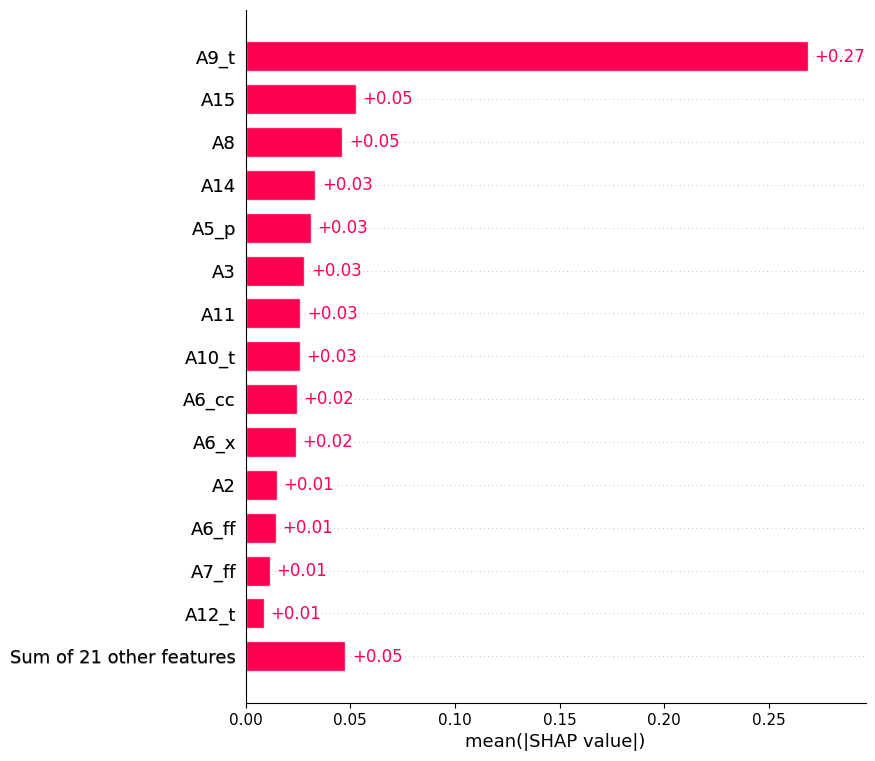

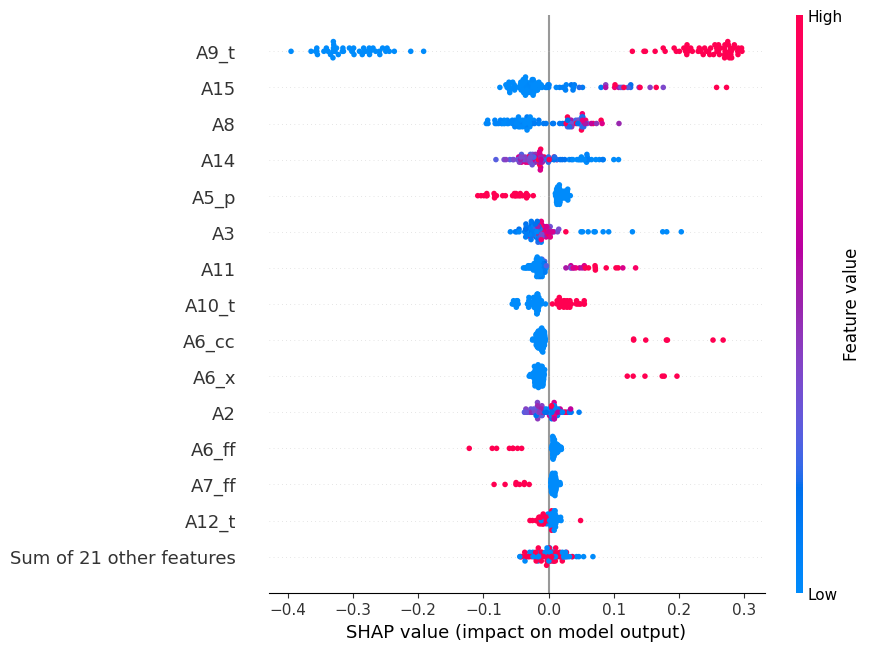

In [ ]:
from interpret.glassbox import ExplainableBoostingClassifier
import shap

ebm = ExplainableBoostingClassifier(random_state=42)
ebm.fit(X_train, y_train)
calc_accuracy(ebm)

X_test_sample = X_test.sample(min(100, len(X_test)), random_state=42)
explainer = shap.Explainer(ebm.predict_proba, X_train)
shap_values = explainer(X_test_sample)

shap_vals_pos = shap_values[..., 1]

shap.plots.bar(shap_vals_pos, max_display=15)

shap.plots.beeswarm(shap_vals_pos, max_display=15)

### XG Boost + LIME

In [ ]:
!pip install xgboost lime --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import xgboost as xgb
import lime
import lime.lime_tabular

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg / pos,   # handles class imbalance
    eval_metric="logloss",
    early_stopping_rounds=20,
    random_state=42,
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=0, stratify=y_train
)
model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
print(f"Best iteration: {model.best_iteration}")

Best iteration: 64


In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"AUROC    : {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Denied", "Approved"]))


Accuracy : 0.8855
AUROC    : 0.9579

              precision    recall  f1-score   support

      Denied       0.93      0.86      0.89        72
    Approved       0.84      0.92      0.88        59

    accuracy                           0.89       131
   macro avg       0.88      0.89      0.89       131
weighted avg       0.89      0.89      0.89       131



True: Denied  |  Predicted: Denied (67.3% confidence)


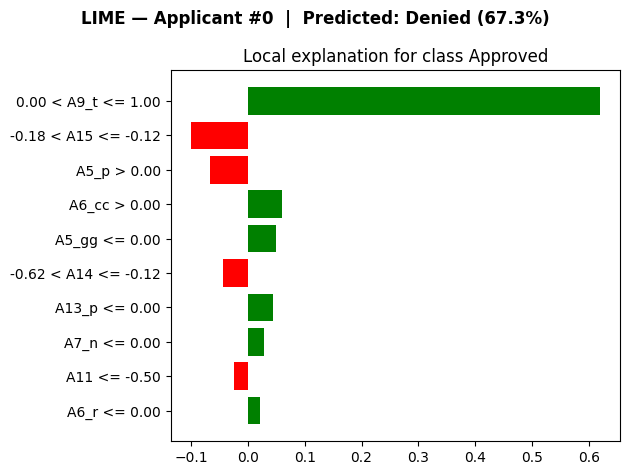

In [ ]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["Denied", "Approved"],
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)

def explain(idx):
    """Explain a single test-set applicant by positional index."""
    instance  = X_test.iloc[idx].values
    exp       = explainer.explain_instance(instance, model.predict_proba, num_features=10)
    pred      = int(model.predict([instance])[0])
    prob      = model.predict_proba([instance])[0][pred]
    true      = int(y_test.iloc[idx])
    label     = "Approved" if pred == 1 else "Denied"
    true_lbl  = "Approved" if true == 1 else "Denied"
    print(f"True: {true_lbl}  |  Predicted: {label} ({prob:.1%} confidence)")
    fig = exp.as_pyplot_figure(label=exp.available_labels()[0])
    fig.suptitle(f"LIME — Applicant #{idx}  |  Predicted: {label} ({prob:.1%})", fontweight="bold")
    plt.tight_layout()
    plt.show()
    return exp

# Try it on the first test applicant
explain(0)

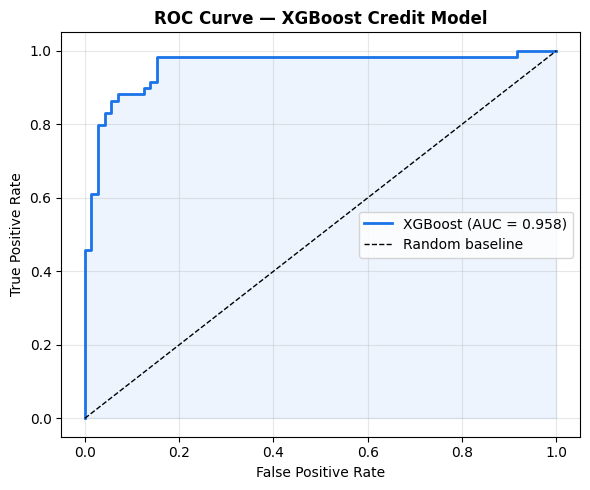

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_prob)
auroc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="#1a73e8", lw=2, label=f"XGBoost (AUC = {auroc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random baseline")
ax.fill_between(fpr, tpr, alpha=0.08, color="#1a73e8")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — XGBoost Credit Model", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plot1_roc.png", dpi=150, bbox_inches="tight")
plt.show()

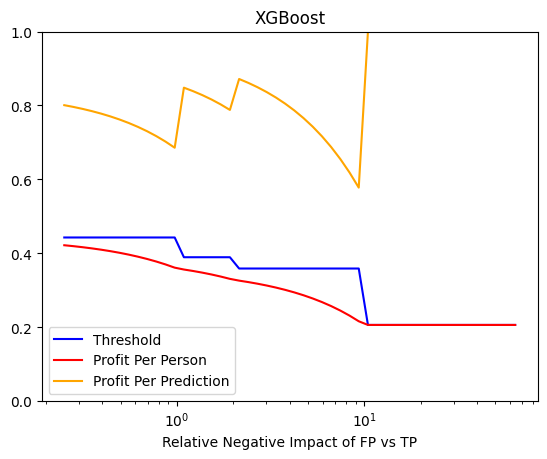

In [ ]:
plot_thresholds(y_test, y_prob, "XGBoost")

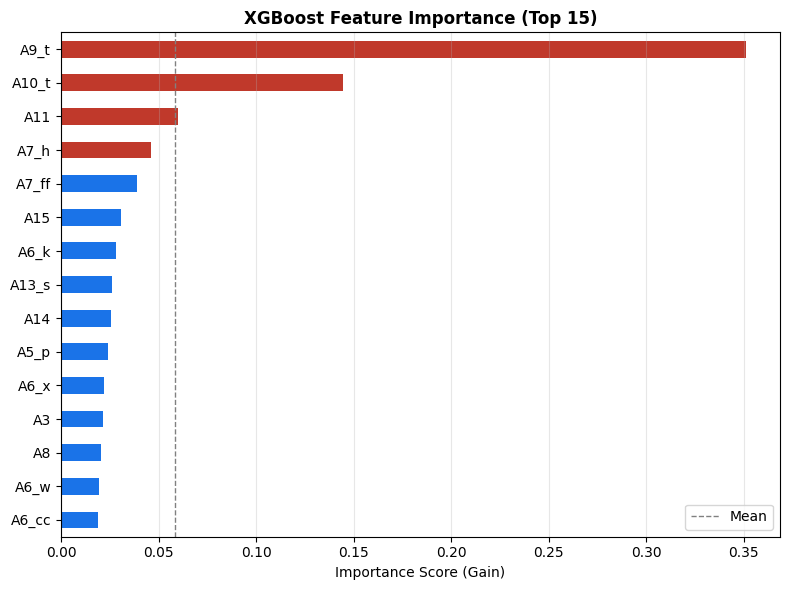

In [ ]:
importances = pd.Series(model.feature_importances_, index=X_train.columns)
top15 = importances.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#c0392b" if v > top15.quantile(0.75) else "#1a73e8" for v in top15]
top15.plot(kind="barh", ax=ax, color=colors)
ax.set_title("XGBoost Feature Importance (Top 15)", fontweight="bold")
ax.set_xlabel("Importance Score (Gain)")
ax.axvline(top15.mean(), color="gray", ls="--", lw=1, label="Mean")
ax.legend()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("plot2_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

True: Approved  |  Predicted: Approved (97.2% confidence)


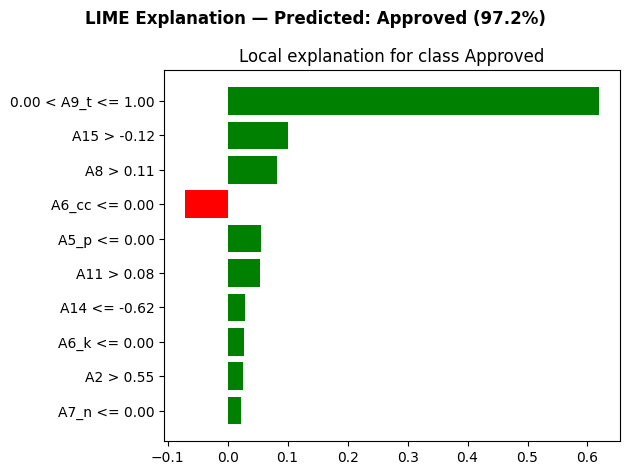

True: Denied  |  Predicted: Denied (95.8% confidence)


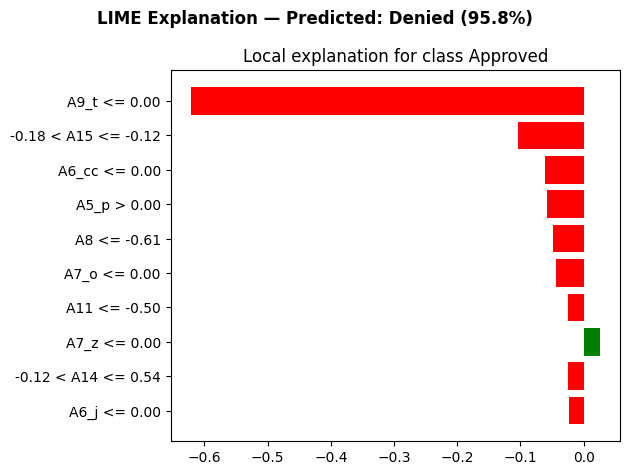

In [ ]:
def explain_and_save(idx, filename):
    instance = X_test.iloc[idx].values
    exp      = explainer.explain_instance(instance, model.predict_proba, num_features=10)
    pred     = int(model.predict([instance])[0])
    prob     = model.predict_proba([instance])[0][pred]
    true     = int(y_test.iloc[idx])
    label    = "Approved" if pred == 1 else "Denied"
    true_lbl = "Approved" if true == 1 else "Denied"
    print(f"True: {true_lbl}  |  Predicted: {label} ({prob:.1%} confidence)")
    fig = exp.as_pyplot_figure(label=exp.available_labels()[0])
    fig.suptitle(f"LIME Explanation — Predicted: {label} ({prob:.1%})", fontweight="bold")
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

# Most confidently approved applicant
prob_series = pd.Series(model.predict_proba(X_test)[:, 1], index=range(len(X_test)))
approved_idx = prob_series[y_test.values == 1].idxmax()
denied_idx   = prob_series[y_test.values == 0].idxmin()

explain_and_save(approved_idx, "plot3a_lime_approved.png")
explain_and_save(denied_idx,   "plot3b_lime_denied.png")

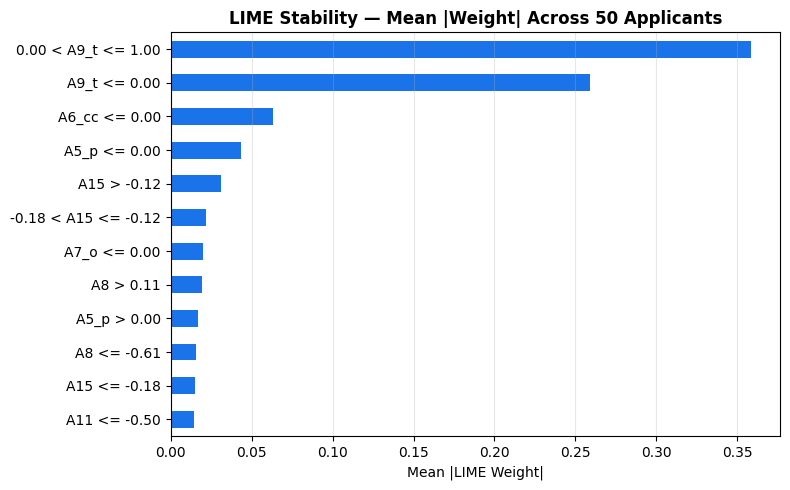

In [ ]:
import numpy as np

N = 50
np.random.seed(42)
sample_idxs = np.random.choice(len(X_test), size=N, replace=False)

all_weights = []
for idx in sample_idxs:
    exp = explainer.explain_instance(
        X_test.iloc[idx].values, model.predict_proba, num_features=10
    )
    all_weights.append(dict(exp.as_list(label=exp.available_labels()[0])))

weight_df  = pd.DataFrame(all_weights).fillna(0)
mean_abs   = weight_df.abs().mean().sort_values(ascending=False).head(12).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
mean_abs.plot(kind="barh", ax=ax, color="#1a73e8")
ax.set_title(f"LIME Stability — Mean |Weight| Across {N} Applicants", fontweight="bold")
ax.set_xlabel("Mean |LIME Weight|")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("plot4_lime_stability.png", dpi=150, bbox_inches="tight")
plt.show()

### Results and Backtesting

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    brier_score_loss, confusion_matrix
)
from sklearn.calibration import calibration_curve

dt_clf = DecisionTreeClassifier(max_depth=3, min_samples_split=10, random_state=0)
dt_clf.fit(X_train, y_train)

logit = LogisticRegression(max_iter=10_000)
logit.fit(X_train, y_train)

# `ebm` and the XGBoost `model` are still in memory from earlier cells
xgb_clf = model

def score_fn(clf):
    """Return a function that maps X -> probability of class 1 (good loan)."""
    if hasattr(clf, "predict_proba"):
        return lambda X: clf.predict_proba(X)[:, 1]
    elif hasattr(clf, "decision_function"):
        # Min-max scale decision function to [0,1] for comparability
        def _f(X):
            d = clf.decision_function(X)
            return (d - d.min()) / (d.max() - d.min() + 1e-12)
        return _f
    else:
        return lambda X: clf.predict(X).astype(float)

MODELS = {
    "Decision Tree":       dt_clf,
    "Logistic Regression": logit,
    "EBM":                 ebm,
    "XGBoost":             xgb_clf,
}

# Pre-compute test scores for everything once
test_scores = {name: score_fn(clf)(X_test) for name, clf in MODELS.items()}
print("Models registered:", list(MODELS.keys()))
print(f"Test set size: {len(y_test)} | Approval base rate: {y_test.mean():.2%}")

Models registered: ['Decision Tree', 'Logistic Regression', 'EBM', 'XGBoost']
Test set size: 131 | Approval base rate: 45.04%


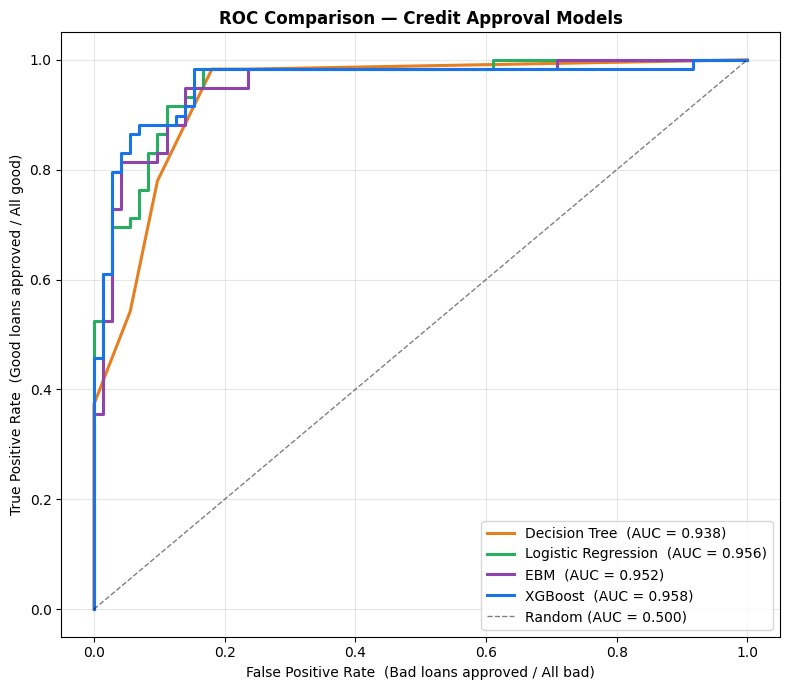


Discriminative power ranking (AUC):
  XGBoost                 0.9579
  Logistic Regression     0.9565
  EBM                     0.9517
  Decision Tree           0.9384


In [ ]:
# ROC Curve Comparison Across Models
fig, ax = plt.subplots(figsize=(8, 7))
palette = {"Decision Tree": "#e67e22", "Logistic Regression": "#27ae60",
           "EBM": "#8e44ad", "XGBoost": "#1a73e8"}

auc_table = {}
for name, scores in test_scores.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    a = auc(fpr, tpr)
    auc_table[name] = a
    ax.plot(fpr, tpr, lw=2.2, color=palette[name], label=f"{name}  (AUC = {a:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random (AUC = 0.500)")
ax.set_xlabel("False Positive Rate  (Bad loans approved / All bad)")
ax.set_ylabel("True Positive Rate  (Good loans approved / All good)")
ax.set_title("ROC Comparison — Credit Approval Models", fontweight="bold")
ax.legend(loc="lower right", frameon=True)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nDiscriminative power ranking (AUC):")
for name, a in sorted(auc_table.items(), key=lambda x: -x[1]):
    print(f"  {name:22s}  {a:.4f}")

In [ ]:
#  Loan-Level P&L Engine
# Economic assumptions
INTEREST_RATE   = 0.12
COST_OF_FUNDS   = 0.03
NET_MARGIN      = INTEREST_RATE - COST_OF_FUNDS
LGD             = 0.60
OPP_COST_FACTOR = 1.0

if "A15" in X_test.columns:
    # A15 was scaled, so re-derive a positive exposure proxy
    ead_raw = X_test["A15"].values
    EAD = (ead_raw - ead_raw.min() + 1) * 1000   # rescale to dollar-like units
else:
    EAD = np.ones(len(y_test)) * 10_000   # $10k per loan, flat
EAD = np.asarray(EAD, dtype=float)

print(f"Total portfolio exposure if all approved: ${EAD.sum():,.0f}")
print(f"Net margin per good loan: {NET_MARGIN:.1%} | LGD on bad loan: {LGD:.0%}")

def loan_pnl(y_true, scores, threshold, ead,
             net_margin=NET_MARGIN, lgd=LGD, opp=OPP_COST_FACTOR):
    """
    Backtest a single decision threshold.
    Approve loan i iff scores[i] >= threshold.
    Returns full P&L decomposition.
    """
    y_true = np.asarray(y_true)
    approve = scores >= threshold

    tp = approve & (y_true == 1)   # approved a good loan -> earn margin
    fp = approve & (y_true == 0)   # approved a bad  loan -> lose LGD * EAD
    fn = (~approve) & (y_true == 1)  # rejected a good loan -> opportunity cost
    tn = (~approve) & (y_true == 0)  # rejected a bad  loan -> correct save

    interest_income  = (tp * ead * net_margin).sum()
    credit_losses    = (fp * ead * lgd).sum()
    opportunity_cost = (fn * ead * net_margin).sum() * opp

    realized_pnl = interest_income - credit_losses
    economic_pnl = realized_pnl - opportunity_cost   # incl. forgone profit

    n_app = approve.sum()
    deployed_capital = (approve * ead).sum()

    return {
        "threshold":        threshold,
        "approval_rate":    n_app / len(y_true),
        "n_approved":       int(n_app),
        "interest_income":  interest_income,
        "credit_losses":    credit_losses,
        "opportunity_cost": opportunity_cost,
        "realized_pnl":     realized_pnl,
        "economic_pnl":     economic_pnl,
        "roa":              realized_pnl / deployed_capital if deployed_capital > 0 else 0,
        "book_bad_rate":    fp.sum() / max(n_app, 1),
        "default_savings":  tn.sum(),
    }

# Sweep thresholds for every model
thresholds = np.linspace(0.01, 0.99, 99)
pnl_curves = {
    name: pd.DataFrame([loan_pnl(y_test, scores, t, EAD) for t in thresholds])
    for name, scores in test_scores.items()
}

# Profit-maximizing threshold per model
print("\n" + "="*95)
print(f"{'Model':22s} {'τ*':>6s} {'P&L ($)':>14s} {'ROA':>8s} {'Approval':>10s} {'BookBad':>9s}")
print("="*95)
optimal = {}
for name, df in pnl_curves.items():
    star = df.loc[df["realized_pnl"].idxmax()]
    optimal[name] = star
    print(f"{name:22s} {star['threshold']:>6.2f} {star['realized_pnl']:>14,.0f} "
          f"{star['roa']:>7.2%} {star['approval_rate']:>9.1%} {star['book_bad_rate']:>9.2%}")

Total portfolio exposure if all approved: $150,073
Net margin per good loan: 9.0% | LGD on bad loan: 60%

Model                      τ*        P&L ($)      ROA   Approval   BookBad
Decision Tree            0.85          2,995   9.00%     16.8%     0.00%
Logistic Regression      0.77          3,967   6.68%     32.8%     4.65%
EBM                      0.86          3,956   6.36%     34.4%     4.44%
XGBoost                  0.69          4,337   6.50%     37.4%     4.08%


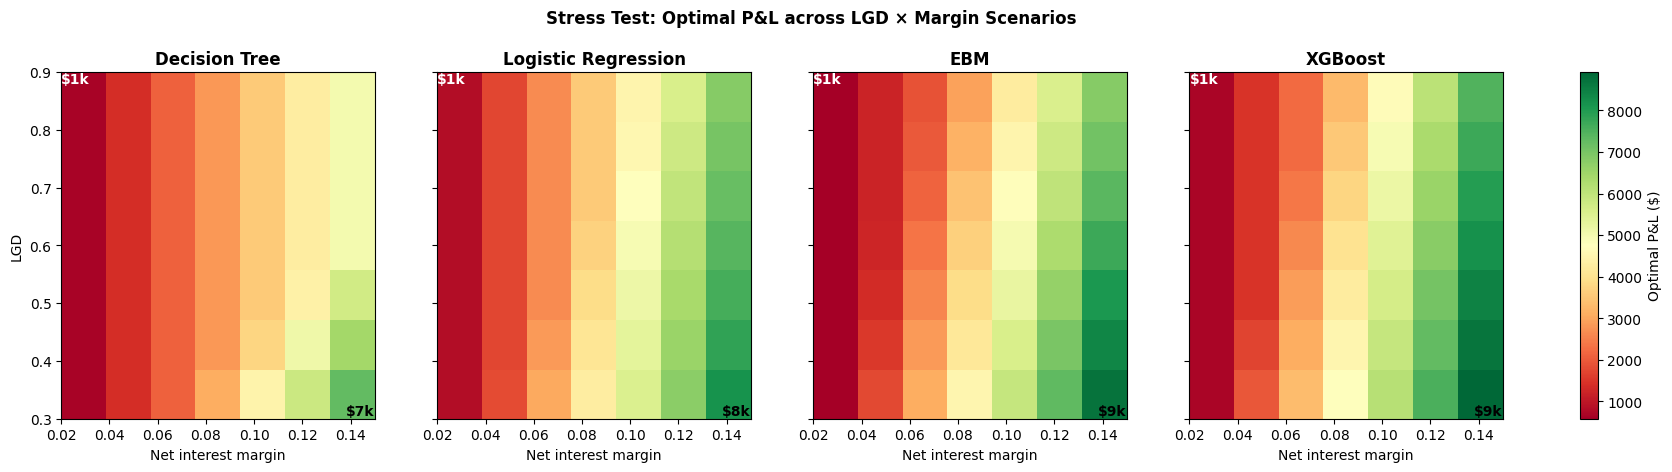


Scenario dominance (out of 49 regimes):
  XGBoost                 wins 30/49  (61%)
  Logistic Regression     wins 19/49  (39%)
  Decision Tree           wins  0/49  (0%)
  EBM                     wins  0/49  (0%)


In [ ]:
# =============================================================================
# Macro Stress Test: P&L Sensitivity to LGD and Interest Margin
# =============================================================================

lgd_grid    = np.linspace(0.30, 0.90, 7)
margin_grid = np.linspace(0.02, 0.15, 7)

stress_results = {name: np.zeros((len(lgd_grid), len(margin_grid))) for name in MODELS}

for name, scores in test_scores.items():
    for i, lgd_v in enumerate(lgd_grid):
        for j, m_v in enumerate(margin_grid):
            # Re-optimize threshold under each scenario
            best_pnl = -np.inf
            for t in thresholds:
                r = loan_pnl(y_test, scores, t, EAD, net_margin=m_v, lgd=lgd_v, opp=0)
                if r["realized_pnl"] > best_pnl:
                    best_pnl = r["realized_pnl"]
            stress_results[name][i, j] = best_pnl

fig, axes = plt.subplots(1, len(MODELS), figsize=(5*len(MODELS), 4.5), sharey=True)
vmin = min(arr.min() for arr in stress_results.values())
vmax = max(arr.max() for arr in stress_results.values())

for ax, (name, grid) in zip(axes, stress_results.items()):
    im = ax.imshow(grid, aspect="auto", origin="lower", cmap="RdYlGn",
                   vmin=vmin, vmax=vmax,
                   extent=[margin_grid[0], margin_grid[-1], lgd_grid[0], lgd_grid[-1]])
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Net interest margin")
    ax.set_ylabel("LGD" if ax is axes[0] else "")
    # Annotate corners
    ax.text(margin_grid[0], lgd_grid[-1], f"${grid[-1,0]/1e3:.0f}k",
            color="white", fontweight="bold", va="top")
    ax.text(margin_grid[-1], lgd_grid[0], f"${grid[0,-1]/1e3:.0f}k",
            color="black", fontweight="bold", ha="right", va="bottom")

fig.colorbar(im, ax=axes, label="Optimal P&L ($)", fraction=0.02)
fig.suptitle("Stress Test: Optimal P&L across LGD × Margin Scenarios",
             fontweight="bold", y=1.02)
plt.savefig("stress_test.png", dpi=150, bbox_inches="tight")
plt.show()

win_count = {n: 0 for n in MODELS}
for i in range(len(lgd_grid)):
    for j in range(len(margin_grid)):
        winner = max(MODELS, key=lambda n: stress_results[n][i, j])
        win_count[winner] += 1
total_cells = len(lgd_grid) * len(margin_grid)
print("\nScenario dominance (out of {} regimes):".format(total_cells))
for n, c in sorted(win_count.items(), key=lambda x: -x[1]):
    print(f"  {n:22s}  wins {c:>2d}/{total_cells}  ({c/total_cells:.0%})")

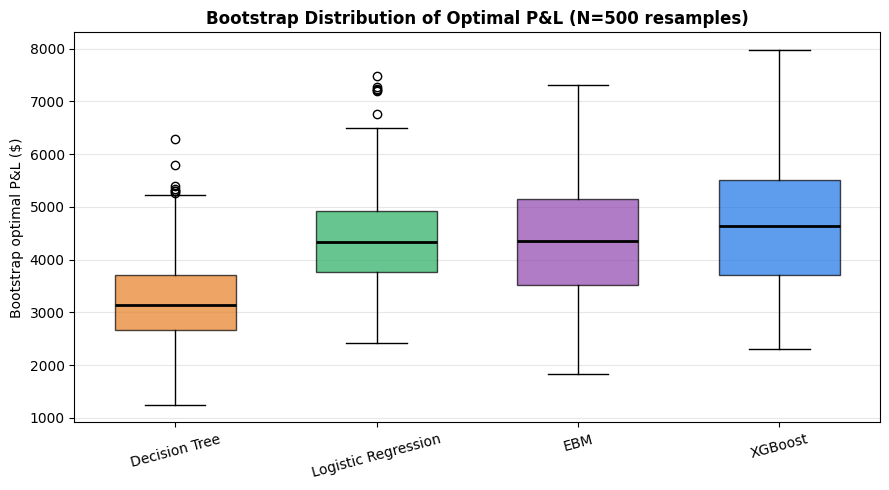


Model                    Median P&L   95% CI Lower   95% CI Upper
------------------------------------------------------------------
Decision Tree                 3,136          1,918          4,869
Logistic Regression           4,326          2,763          6,268
EBM                           4,351          2,247          6,485
XGBoost                       4,628          2,760          6,797


In [ ]:
# =============================================================================
# Bootstrap CIs on Optimal P&L (statistical robustness)
# =============================================================================

N_BOOT = 500
rng = np.random.RandomState(42)
n = len(y_test)

boot_pnls = {name: [] for name in MODELS}
y_test_arr = np.asarray(y_test)

for b in range(N_BOOT):
    idx = rng.randint(0, n, size=n)
    yb, eb = y_test_arr[idx], EAD[idx]
    for name, scores in test_scores.items():
        sb = scores[idx]
        best = max(loan_pnl(yb, sb, t, eb)["realized_pnl"] for t in thresholds)
        boot_pnls[name].append(best)

fig, ax = plt.subplots(figsize=(9, 5))
positions = range(len(MODELS))
data = [boot_pnls[n] for n in MODELS]
bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True,
                medianprops=dict(color="black", lw=2))
for patch, name in zip(bp["boxes"], MODELS):
    patch.set_facecolor(palette[name])
    patch.set_alpha(0.7)
ax.set_xticks(positions)
ax.set_xticklabels(list(MODELS.keys()), rotation=15)
ax.set_ylabel("Bootstrap optimal P&L ($)")
ax.set_title(f"Bootstrap Distribution of Optimal P&L (N={N_BOOT} resamples)",
             fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("bootstrap_pnl.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'Model':22s} {'Median P&L':>12s} {'95% CI Lower':>14s} {'95% CI Upper':>14s}")
print("-"*66)
for name in MODELS:
    arr = np.array(boot_pnls[name])
    print(f"{name:22s} {np.median(arr):>12,.0f} "
          f"{np.percentile(arr,2.5):>14,.0f} {np.percentile(arr,97.5):>14,.0f}")

In [ ]:
# EXECUTIVE SUMMARY
summary = pd.DataFrame({
    "AUC":              {n: auc_table[n] for n in MODELS},
    "Optimal τ":        {n: optimal[n]["threshold"]     for n in MODELS},
    "P&L at τ*":        {n: optimal[n]["realized_pnl"]  for n in MODELS},
    "ROA at τ*":        {n: optimal[n]["roa"]           for n in MODELS},
    "Approval Rate":    {n: optimal[n]["approval_rate"] for n in MODELS},
    "Book Bad Rate":    {n: optimal[n]["book_bad_rate"] for n in MODELS},
    "Stress Wins":      {n: win_count[n]                for n in MODELS},
    "Bootstrap Median": {n: np.median(boot_pnls[n])     for n in MODELS},
}).round(4)

print("FINAL MODEL COMPARISON")
print("="*90)
print(summary.to_string())

FINAL MODEL COMPARISON
                        AUC  Optimal τ  P&L at τ*  ROA at τ*  Approval Rate  Book Bad Rate  Stress Wins  Bootstrap Median
Decision Tree        0.9384       0.85  2994.5225     0.0900         0.1679         0.0000            0         3136.0077
Logistic Regression  0.9565       0.77  3967.3338     0.0668         0.3282         0.0465           19         4326.0917
EBM                  0.9517       0.86  3955.7336     0.0636         0.3435         0.0444            0         4350.7605
XGBoost              0.9579       0.69  4336.5699     0.0650         0.3740         0.0408           30         4627.5647
